# Image Simulation

This example demonstrates how to simulate the image formation process through an optical system, accounting for:

1.  **Spatially Variable Blur**: Using EigenPSF decomposition to model PSF variation across the field.
2.  **Geometric Distortion**: Warping the image based on the lens distortion map.
3.  **Lateral Color**: Simulating wavelength-dependent magnification/distortion (if multi-wavelength).

We will use the `ImageSimulationEngine` class.

In [1]:
import matplotlib.pyplot as plt
import optiland.backend as be
from optiland.samples.objectives import ReverseTelephoto
from optiland.analysis.image_simulation import ImageSimulationEngine

## 1. Lens Loading

We load a standard `ReverseTelephoto` lens, which has significant distortion and field-dependent aberrations.

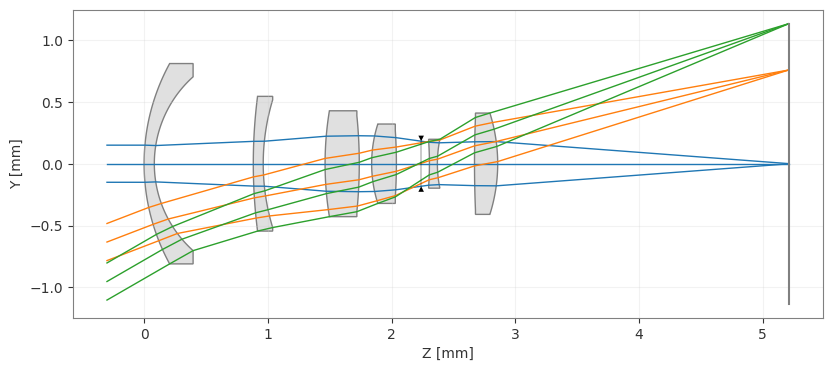

In [2]:
optic = ReverseTelephoto()
_ = optic.draw()

## 2. Select Source Image

Note that the chosen image is based on `HopemanMemorialCarillonRecitalSeries2018.jpg` by DanielPenfield, used under CC BY-SA 4.0. Simulated images derived from this source are subject to the same license.

In [3]:
img_path = 'RushRheesLibrary_800x600.jpg'

## 3. Run Simulation

We configure the `ImageSimulationEngine`.

- **wavelengths**: Wavelengths to simulate (RGB).
- **psf_grid_shape**: Number of field points to sample for EigenPSFs (5x5 is usually sufficient).
- **psf_size**: Pixel size of the computed PSFs.
- **num_rays**: Ray density for PSF calculation (higher = more accurate but slower).


In [4]:
config = {
    "wavelengths": [0.65, 0.55, 0.45],  # RGB Simulation
    "psf_grid_shape": (5, 5),
    "psf_size": 128,
    "num_rays": 64,
    "oversample": 1
}

simulator = ImageSimulationEngine(optic, config=config)

# Single image input:
# run() accepts an image path, loads it internally, and returns (1, C, H, W).
result = simulator.run(img_path)

print("Output shape:", result.shape)

Output shape: (1, 3, 600, 800)


## 4. View Results

We compare the original and simulated images. A clear blur is visible in the simulated image, indicating the presence of aberrations.

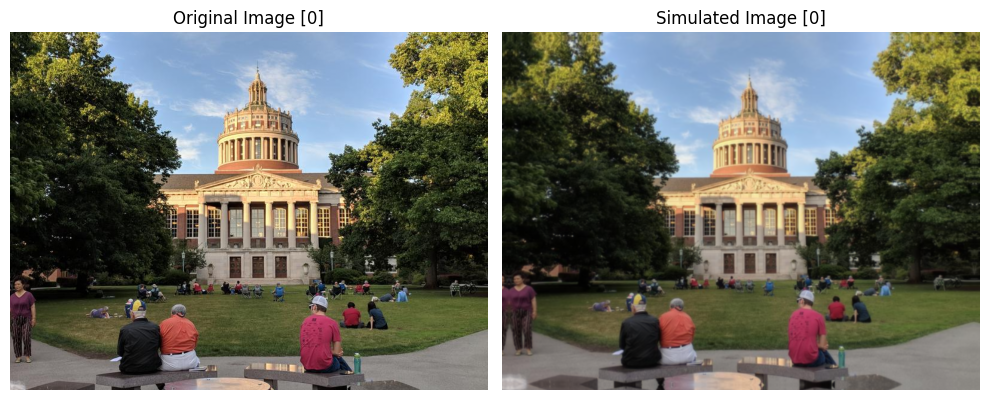

In [5]:
_ = simulator.view()

## 5. Batch Inference

The image simulation engine also supports batched inputs using the `(B, C, H, W)` format. This is useful for model training or inference workflows where multiple images are processed together.

The `view()` method can visualize a specific image from the latest batch result using the `index` argument.

Batch input shape: (2, 3, 600, 800)
Batch output shape: (2, 3, 600, 800)


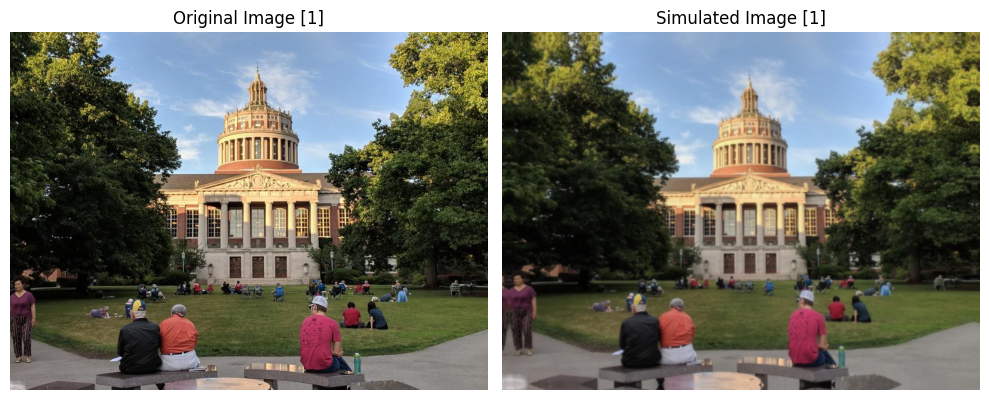

In [6]:
# Batched input:
# For batch workflows, pass images directly as (B, C, H, W).
image = plt.imread(img_path)

if image.ndim == 3 and image.shape[-1] == 4:
    image = image[:, :, :3]

image = image.transpose(2, 0, 1)
images = be.array([image, image])

batch_result = simulator.run(images)

print("Batch input shape:", images.shape)
print("Batch output shape:", batch_result.shape)

# Visualize a specific image from the batch
_ = simulator.view(index=1)